c:\Users\matic\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0 0]
[ 1.6226422   2.0252647  -0.43359444 -0.07861735  0.1760909  -0.97208923
 -0.49529874  0.4943786   0.6643493  -0.9501635   2.1795304  -1.9551506
  0.35857072  0.15779513  1.2770847   1.5104648   0.970656    0.59960806
  0.0247007  -1.9164772  -1.8593491   1.728144    0.04719035  0.814128
  0.13132767  0.28284705  1.2435943   0.6902801  -0.80073744 -0.74099
 -1.5388287   0.30269185 -0.02071605  0.11328721 -0.2206547   0.07052256
  0.8532958  -0.8217738  -0.01461421 -0.15046217 -0.9001352  -0.7590727
  0.33309513  0.80924904  0.04269255 -0.57767123 -0.41439894 -1.9412533
  1.3161184   0.7542728   0.16170931 -0.03483307 -1.3306409   0.39362028
  0.48259583  0.80382955 -0.6337168   1.038756   -0.74159133 -0.4299588
 -0.22510043 -0.51966715 -1.6692165   0.67535436  0.22738722 -1.1800426
 -0.97673357  1.1969604  -0.84127563  0.6598078   1.0680159   0.31542128
  0.43766403  1.1718564   0.9077099   1.2226242  -0.54639524  0.85630435
 -0.00796578  0.47343913 -1.1090349   2.6423514   0.889

sample: 100%|██████████| 3000/3000 [00:01<00:00, 2011.85it/s, 7 steps of size 9.75e-01. acc. prob=0.94]


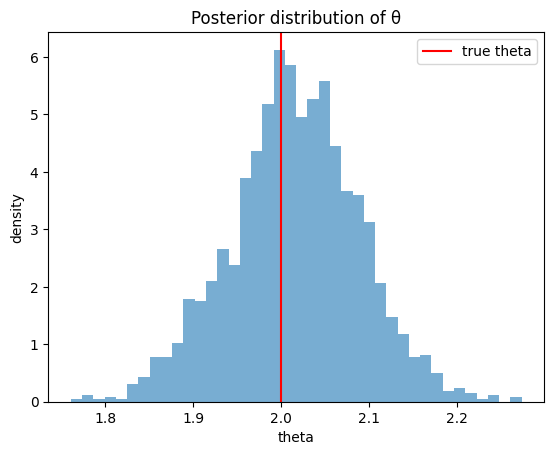

In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate toy data
theta_true = 2.0
sigma = 1.0
N = 200

key = jax.random.PRNGKey(0)
x = theta_true + sigma * jax.random.normal(key, (N,))

# 2. Define model
def model(x):
    theta = numpyro.sample("theta", dist.Normal(0, 5))
    numpyro.sample("obs", dist.Normal(theta, 1), obs=x)

# 3. Run HMC / NUTS
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000)
mcmc.run(key, x=x)

samples = mcmc.get_samples()
theta_samples = samples["theta"]

# 4. Plot posterior histogram
plt.hist(theta_samples, bins=40, density=True, alpha=0.6)
plt.axvline(theta_true, color="red", label="true theta")
plt.xlabel("theta")
plt.ylabel("density")
plt.title("Posterior distribution of θ")
plt.legend()
plt.show()